In [6]:
from qiskit import __version__
assert __version__ >= '2.0.0', 'Qiskit version is too low!'
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit.quantum_info import random_clifford, Statevector
import matplotlib.pyplot as plt

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_city

from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli
import numpy as np

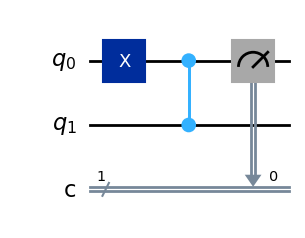

In [26]:
def circuit():
    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(1, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.x(qr[0])
    
    qc.cz(qr[0], qr[1])  # This is a no-op, but it can be used to test the circuit structure
    qc.measure(qr[0], cr[0])  # Measure the first qubit into the classical register

    return qc
circuit().draw('mpl')

<h2> Simulation

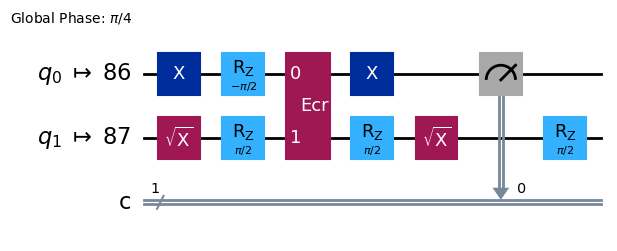

In [27]:
backend = FakeSherbrooke()
sim = AerSimulator.from_backend(backend=backend)

transpiled_circuit = transpile(circuit(), backend=backend, optimization_level=3)
transpiled_circuit.draw('mpl')

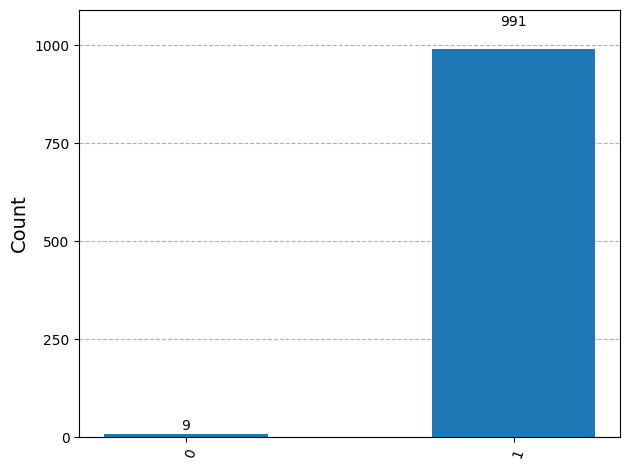

In [28]:
job = sim.run(transpiled_circuit, shots=1000)
result = job.result()

plot_histogram(result.get_counts())